In [1]:
import sys
sys.path.append("../")

In [2]:
from src.analysis_utils import (
    load_and_prepare_data,
    compute_indicators,
    plot_stock_analysis
)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import talib

In [5]:
df = pd.read_csv("../data/raw/AAPL.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [6]:
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date")

df = df.dropna()

df.set_index("Date", inplace=True)

df.head()

In [8]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date")

df = df.dropna()

df.set_index("Date", inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [10]:
df["SMA_20"] = talib.SMA(df["Close"], timeperiod=20)

df["SMA_50"] = talib.SMA(df["Close"], timeperiod=50)

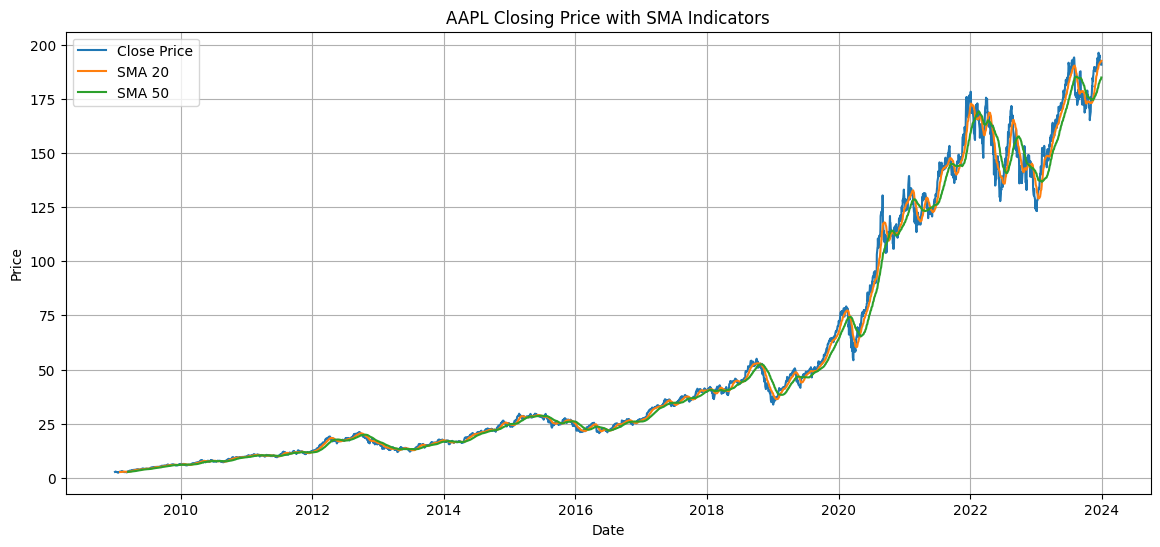

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close Price")

plt.plot(df.index, df["SMA_20"], label="SMA 20")

plt.plot(df.index, df["SMA_50"], label="SMA 50")

plt.title("AAPL Closing Price with SMA Indicators")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()